In [66]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import os 
from scipy.interpolate import interp1d
from pathlib import Path



In [5]:
path = '/home/nmonnier/Data/JWST/NGC_7023/Fusion/Templates/Archive/'

pce = np.loadtxt(path + 'MIRI.F560W.dat')


In [75]:
pces = []
wavels = []
wavelength = np.load('/home/nmonnier/Data/JWST/NGC_7023/Fusion/Templates/wavel_axis_NGC7023_1ABC_2ABC_3ABC_4ABC.npy')

for file in sorted(os.listdir(path)):
    if not '.npy' in file:
        pce = np.loadtxt(path + file)[:,1]
        pces.append(pce)
        wavel = np.loadtxt(path + file)[:,0]/10000
        wavels.append(wavel)

        f_interp = interp1d(wavel, pce, kind="linear", bounds_error=False, fill_value=0)
        pce_interp = f_interp(wavelength)

        filename = Path(file).stem
        print(np.vstack((pce_interp, wavelength)).shape)
        np.save(path + filename + '_1ABC_2ABC_3ABC_4ABC.npy', np.vstack((pce_interp, wavelength)))
    
print(pces[0])
print(wavels[0]/10000)


(2, 10396)
(2, 10396)
(2, 10396)
(2, 10396)
(2, 10396)
(2, 10396)
(2, 10396)
(2, 10396)
(2, 10396)
[4.000e-04 1.200e-03 2.000e-03 2.900e-03 5.600e-03 8.200e-03 1.090e-02
 1.270e-02 1.390e-02 1.510e-02 1.560e-02 1.300e-02 1.040e-02 7.800e-03
 6.200e-03 5.000e-03 3.800e-03 2.900e-03 2.900e-03 2.900e-03 2.900e-03
 3.300e-03 3.800e-03 4.300e-03 5.200e-03 6.500e-03 7.800e-03 9.200e-03
 1.190e-02 1.470e-02 1.740e-02 2.110e-02 2.580e-02 3.050e-02 3.520e-02
 4.160e-02 4.810e-02 5.450e-02 6.230e-02 7.110e-02 7.990e-02 8.940e-02
 1.029e-01 1.163e-01 1.298e-01 1.482e-01 1.687e-01 1.893e-01 2.109e-01
 2.357e-01 2.605e-01 2.853e-01 3.036e-01 3.202e-01 3.369e-01 3.482e-01
 3.494e-01 3.506e-01 3.518e-01 3.470e-01 3.414e-01 3.358e-01 3.312e-01
 3.277e-01 3.242e-01 3.208e-01 3.223e-01 3.239e-01 3.255e-01 3.292e-01
 3.347e-01 3.401e-01 3.457e-01 3.518e-01 3.580e-01 3.641e-01 3.693e-01
 3.740e-01 3.787e-01 3.830e-01 3.855e-01 3.880e-01 3.905e-01 3.916e-01
 3.922e-01 3.928e-01 3.930e-01 3.926e-01 3.921e-0

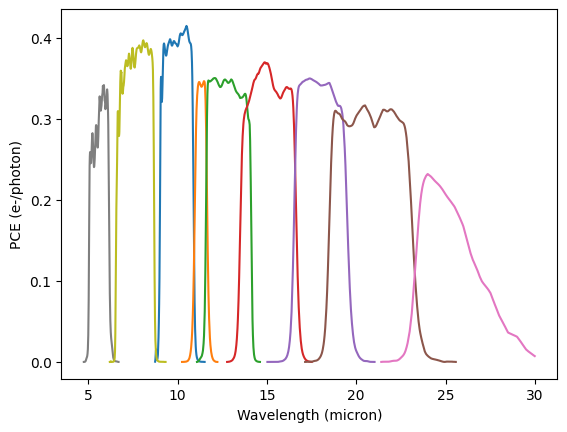

In [58]:
for i, pce in enumerate(pces):
    plt.plot(wavels[i], pce, label=os.path.splitext(os.path.basename(os.listdir(path)[i]))[0])
plt.xlabel('Wavelength (micron)')
plt.ylabel('PCE (e-/photon)')
plt.show()

[ 8.743  8.749  8.755  8.76   8.766  8.772  8.778  8.784  8.789  8.795
  8.801  8.807  8.813  8.818  8.824  8.83   8.836  8.842  8.847  8.853
  8.859  8.865  8.871  8.876  8.882  8.888  8.894  8.9    8.905  8.911
  8.917  8.923  8.929  8.934  8.94   8.946  8.952  8.958  8.963  8.969
  8.975  8.981  8.987  8.992  8.998  9.004  9.01   9.016  9.021  9.027
  9.033  9.039  9.045  9.05   9.056  9.062  9.068  9.074  9.079  9.085
  9.091  9.097  9.103  9.108  9.114  9.12   9.126  9.132  9.137  9.143
  9.149  9.155  9.161  9.166  9.172  9.178  9.184  9.19   9.195  9.201
  9.207  9.213  9.219  9.224  9.23   9.236  9.242  9.248  9.253  9.259
  9.265  9.271  9.277  9.282  9.288  9.294  9.3    9.306  9.311  9.317
  9.323  9.329  9.335  9.34   9.346  9.352  9.358  9.364  9.369  9.375
  9.381  9.387  9.393  9.398  9.404  9.41   9.416  9.422  9.427  9.433
  9.439  9.445  9.451  9.456  9.462  9.468  9.474  9.48   9.485  9.491
  9.497  9.503  9.509  9.514  9.52   9.526  9.532  9.538  9.543  9.549
  9.55

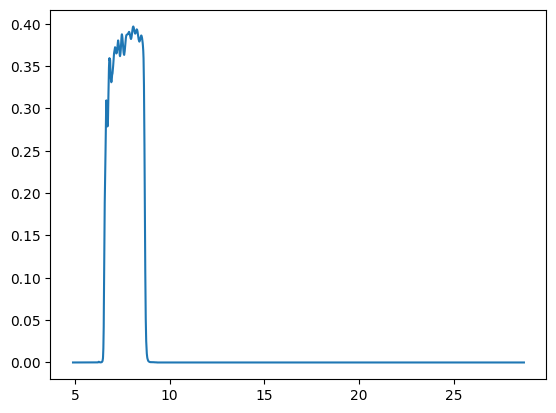

In [61]:

# Load wavelength
wavelength = np.load('/home/nmonnier/Data/JWST/NGC_7023/Fusion/Templates/wavel_axis_NGC7023_1ABC_2ABC_3ABC_4ABC.npy')
from scipy.interpolate import interp1d
interpn_PCE = []
for i, pce in enumerate(pces):
    print(wavels[i])
    f_interp = interp1d(wavels[i], pce, kind="linear", bounds_error=False, fill_value=0)
    pce_interp = f_interp(wavelength)
    interpn_PCE.append(pce_interp)

print(interpn_PCE[0].shape, pces[0].shape, wavelength.shape)
print(np.where(interpn_PCE[0]>0))
plt.plot(wavelength, interpn_PCE[-1])
plt.show()

In [ ]:
import webbpsf
miri = webbpsf.MIRI()
miri.mode = 'imaging'   
miri.filter = 'F1280W'
psf = miri.calc_psf()

ValueError: Instrument MIRI doesn't have a filter called F1980W.

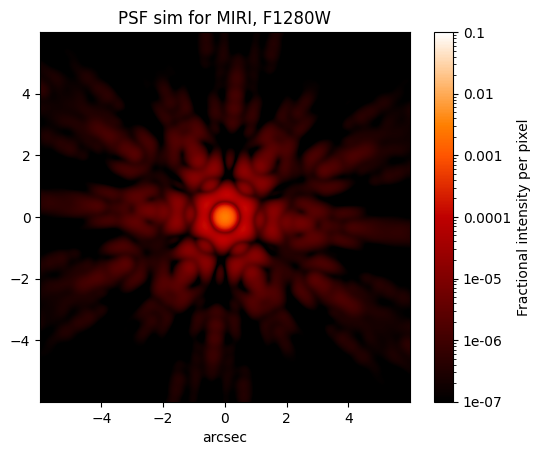

In [92]:
webbpsf.display_psf(psf)

In [88]:
import stpsf

ModuleNotFoundError: No module named 'stpsf'